In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV

In [4]:
df = pd.read_csv("creditcard.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape:
(67434, 31)

First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.2

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [9]:
df.fillna(df.median(numeric_only=True), inplace=True)
df = df.dropna(subset=['Class'])


Fraud Distribution:
Class
0.0    67265
1.0      169
Name: count, dtype: int64


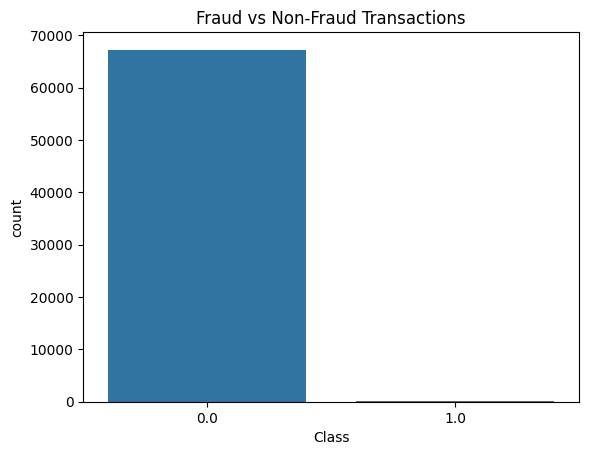

In [10]:
print("\nFraud Distribution:")
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [11]:
X = df.drop('Class', axis=1)
y = df['Class']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Before SMOTE:
Class
0.0    53812
1.0      135
Name: count, dtype: int64

After SMOTE:
Class
0.0    53812
1.0    53812
Name: count, dtype: int64


In [15]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]


In [16]:
print("\nLOGISTIC REGRESSION RESULTS")

print(classification_report(
    y_test,
    lr_pred
))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

print("ROC AUC:",
      roc_auc_score(y_test, lr_prob))



LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     13453
         1.0       0.13      0.82      0.22        34

    accuracy                           0.99     13487
   macro avg       0.56      0.90      0.61     13487
weighted avg       1.00      0.99      0.99     13487

Precision: 0.12962962962962962
Recall: 0.8235294117647058
F1 Score: 0.224
ROC AUC: 0.9747421305547418


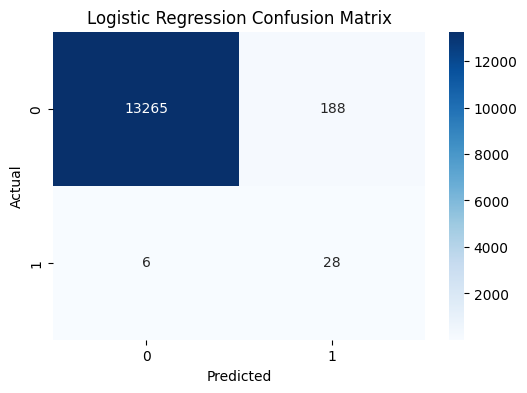

In [17]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [18]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_smote,
    y_train_smote
)

rf_pred = rf.predict(X_test_scaled)

rf_prob = rf.predict_proba(
    X_test_scaled
)[:,1]


In [19]:
print("\nRANDOM FOREST RESULTS")

print(classification_report(
    y_test,
    rf_pred
))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("ROC AUC:",
      roc_auc_score(y_test, rf_prob))


RANDOM FOREST RESULTS
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     13453
         1.0       0.87      0.79      0.83        34

    accuracy                           1.00     13487
   macro avg       0.94      0.90      0.92     13487
weighted avg       1.00      1.00      1.00     13487

Precision: 0.8709677419354839
Recall: 0.7941176470588235
F1 Score: 0.8307692307692308
ROC AUC: 0.9792469206518556


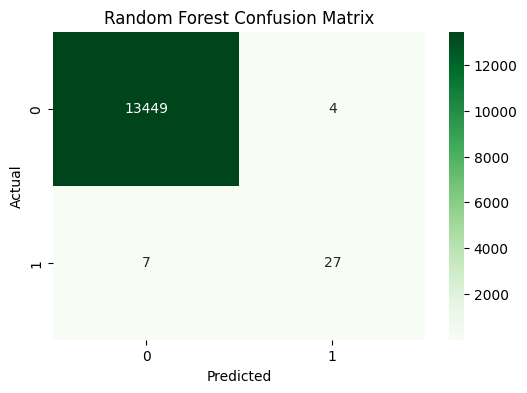

In [20]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


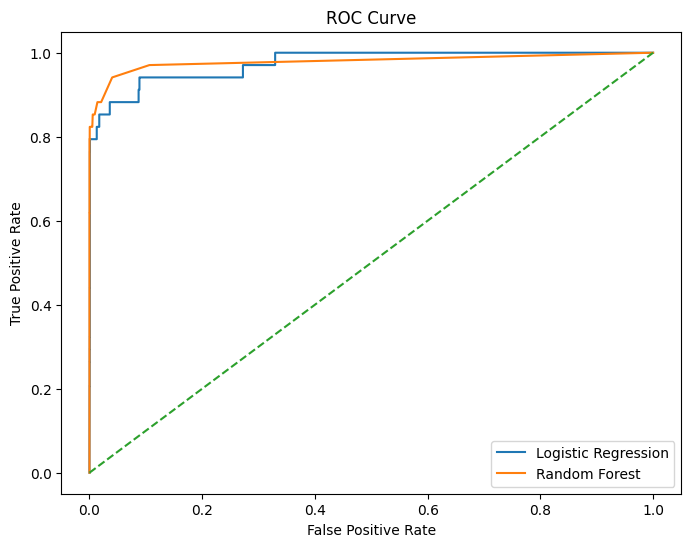

In [21]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()


In [22]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(
    X_train_smote,
    y_train_smote
)

print("\nBest Parameters:")
print(grid.best_params_)

best_rf = grid.best_estimator_

best_pred = best_rf.predict(
    X_test_scaled
)

best_prob = best_rf.predict_proba(
    X_test_scaled
)[:,1]

print("\nTUNED RANDOM FOREST")

print(classification_report(
    y_test,
    best_pred
))

print("ROC AUC:",
      roc_auc_score(
          y_test,
          best_prob
      ))



Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

TUNED RANDOM FOREST
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     13453
         1.0       0.87      0.79      0.83        34

    accuracy                           1.00     13487
   macro avg       0.94      0.90      0.92     13487
weighted avg       1.00      1.00      1.00     13487

ROC AUC: 0.9781505109291171



Top 10 Important Features
   Feature  Importance
14     V14    0.187596
10     V10    0.114026
12     V12    0.104961
3       V3    0.095557
17     V17    0.085862
4       V4    0.079845
11     V11    0.072645
16     V16    0.061667
2       V2    0.040218
6       V6    0.018842


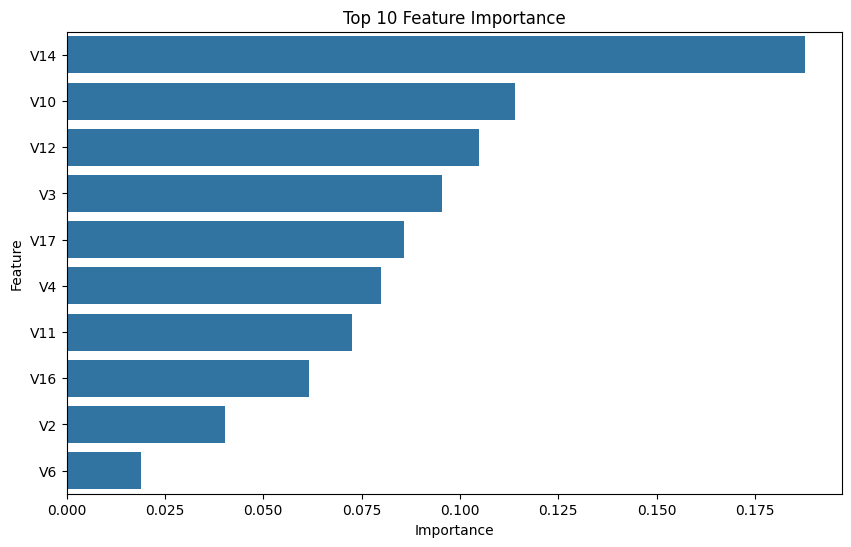

In [23]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features")

print(
    importance.head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Feature Importance"
)

plt.show()


In [24]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": best_pred
})

results.to_csv(
    "fraud_prediction_results.csv",
    index=False
)

print("\nProject Completed Successfully")


Project Completed Successfully
